#### Import necessary libraries

In [1]:
import pandas as pd                # data manipulation and analysis
import matplotlib.pyplot as plt    # creating visualizations
import seaborn as sns              # advanced and attractive statistical plots
import re                          #text preprocessing like removing special characters, numbers, or patterns from text.
import string                      #Contains string constants and utility functions and used to remove punctuation from text

import nltk                         #natural language processing(NLP).Provides tools for tokenization, stemming, 
                                    #lemmatization, POS tagging, etc

from nltk.corpus import stopwords       #Imports a list of common stopwords("the", "is","and",..) from NLTK and 
                                        #helps in removing stopwords from text to reduce noise in NLP tasks.

from nltk.stem import WordNetLemmatizer #reducing words to their base form.


from sklearn.model_selection import train_test_split        #split datasets into training and testing sets

from sklearn.feature_extraction.text import TfidfVectorizer #converts text into TF-IDF features(num vectors representing text importance)
                                                            #transforms text data into a format suitable for machine learning models


#### Data Loading

In [2]:
data=pd.read_csv(r"C:\Users\kjnav\Documents\Navaneee\automated-review-rating-system\data\cleaned\imbalanced_data.csv")

#### Exploratory Data Analysis.

In [3]:
#First 2 rows of the data
data.head(5)

,rating,review_text
0,5,"Love this product, however the Amazon price is..."
1,4,This has recently become my staple breakfast c...
2,4,This spread is just right but costs only about...
3,2,I guess I learned from this purchase that rais...
4,2,This coffee is sort of grocery store quality-a...


In [ ]:
#Column name and data type of each columns.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341595 entries, 0 to 341594
Data columns (total 2 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   rating       341595 non-null  int64 
 1   review_text  341595 non-null  object
dtypes: int64(1), object(1)
memory usage: 5.2+ MB


In [6]:
#Summary statistics of the data
data.describe()

,rating
count,341595.000000
mean,3.350005
std,1.235919
min,1.000000
25%,3.000000
50%,4.000000
75%,4.000000
max,5.000000


C:\Users\kjnav\AppData\Local\Temp\ipykernel_25424\2577757198.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=data, palette='viridis')


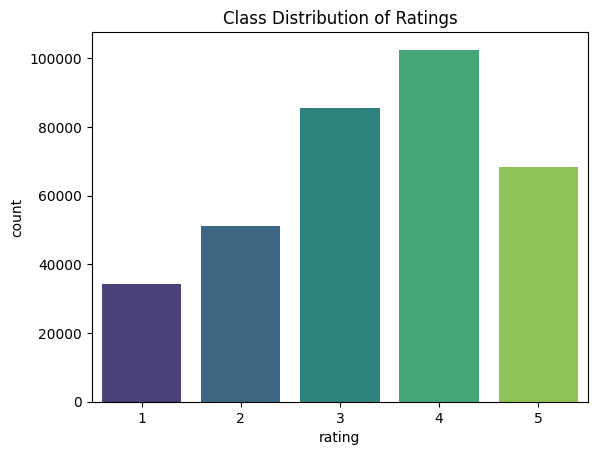

In [27]:
#Class dsitribution of ratings
sns.countplot(x='rating', data=data, palette='viridis')
plt.title("Class Distribution of Ratings")
plt.savefig("imb_1.png")


#### Text Preprocessing

- we clean the review_text column using a user defined function "cleaned_text"

In [4]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # lowercase
    text = text.lower()
    
    # remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    
    # specifically remove <br> tags (case-insensitive)
    text = re.sub(r"<br\s*/?>", " ", text, flags=re.IGNORECASE)
    
    # remove other HTML tags
    text = re.sub(r"<.*?>", " ", text)
    
    # remove standalone 'br' words
    text = re.sub(r"\bbr\b", " ", text)
    
    # remove emojis and non-alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)
    
    # tokenize, remove stopwords, and lemmatize
    tokens = text.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    
    # rejoin words
    return " ".join(tokens)

# Apply again
data["cleaned_review"] = data["review_text"].astype(str).apply(preprocess)

# Check if any 'br' still remains (should be 0 now)
print(data["cleaned_review"].str.contains(r"\bbr\b").sum())

9


In [5]:
#finding count of words in review text
data["word_count"] = data["cleaned_review"].apply(lambda x: len(x.split()))

In [6]:
data.head(4)

,rating,review_text,cleaned_review,word_count
0,5,"Love this product, however the Amazon price is...",love product however amazon price absurd buy d...,13
1,4,This has recently become my staple breakfast c...,recently become staple breakfast cereal trying...,47
2,4,This spread is just right but costs only about...,spread right cost six dollar locally price shi...,9
3,2,I guess I learned from this purchase that rais...,guess learned purchase raisin raisin raisin co...,17


In [50]:
print('maximum: ',max(data['word_count']))
print('minimum :',min(data['word_count']))

maximum:  1956
minimum : 0


In [7]:
print(data.loc[data['word_count'] == 0, 'cleaned_review'].tolist())
print(data.loc[data['word_count'] == 1919, 'cleaned_review'].tolist())


['', '', '']
[]


In [8]:
#removing words too short and too long review_text
data = data[(data["word_count"] >= 3) & (data["word_count"] <= 175)]  
print("size of remaining sample :",data.shape[0])

size of remaining sample : 336480


#### Data Visualization (After Text Preprocessing)

C:\Users\kjnav\AppData\Local\Temp\ipykernel_25424\394396898.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="rating", data=data, palette="Paired", ax=axes[0])
C:\Users\kjnav\AppData\Local\Temp\ipykernel_25424\394396898.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="rating", y="word_count", data=data, palette="Paired", ax=axes[2])


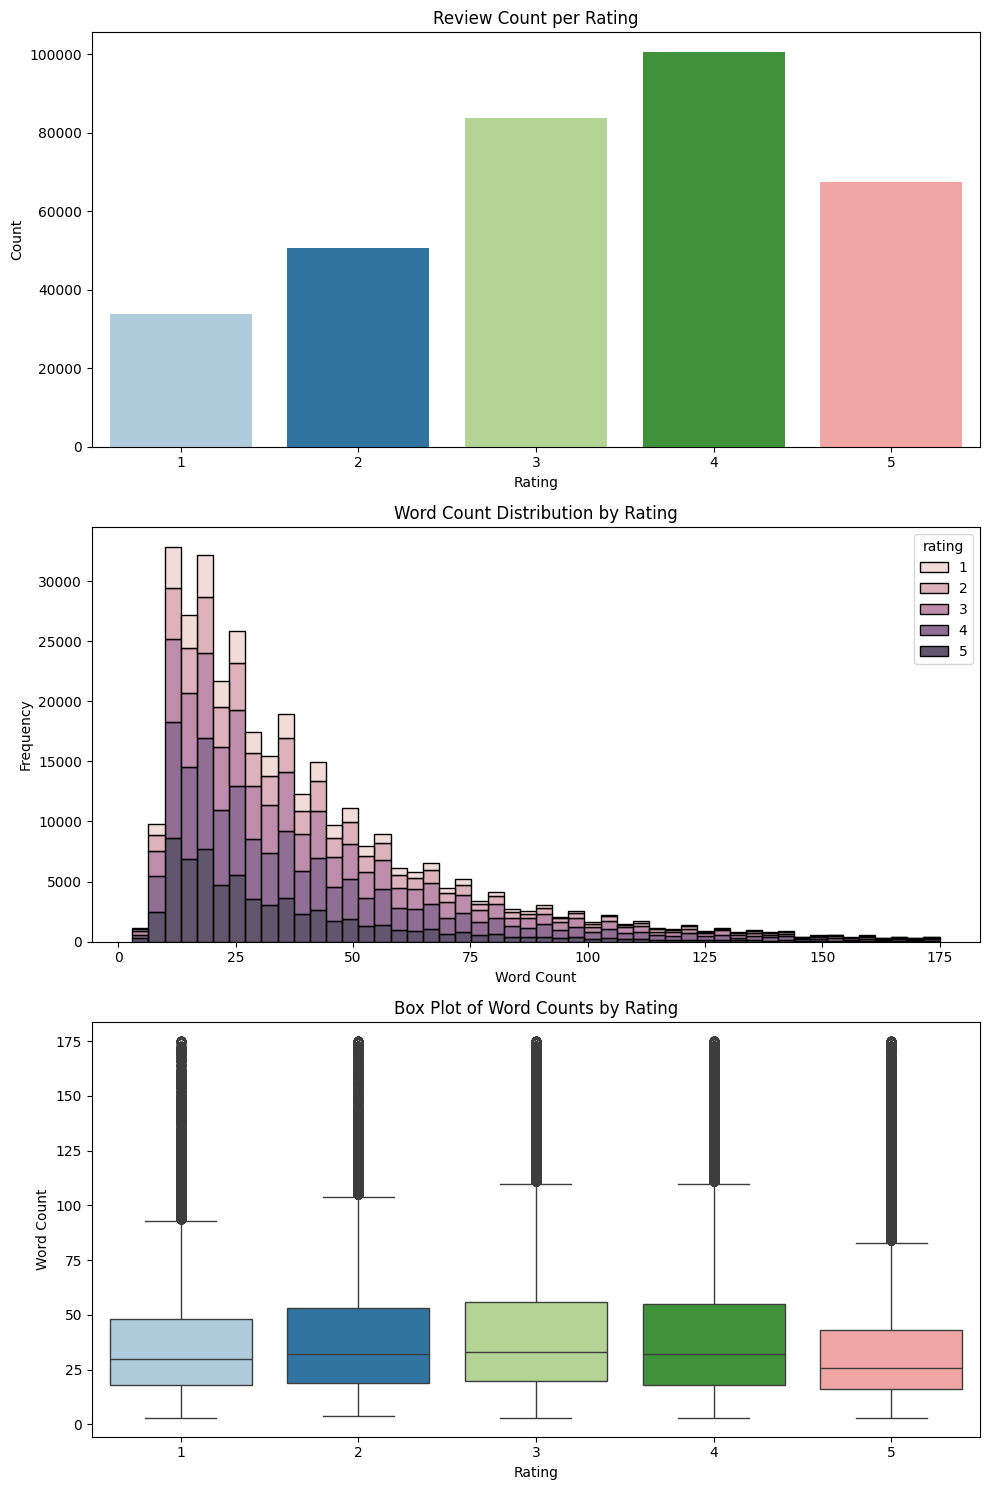

In [41]:
#subplots of 3 rows and 1 column
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

#bar plot: Review count per rating
sns.countplot(x="rating", data=data, palette="Paired", ax=axes[0])
axes[0].set_title("Review Count per Rating")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

#histogram of word counts
sns.histplot(data, x="word_count", hue="rating", multiple="stack", bins=50, ax=axes[1])
axes[1].set_title("Word Count Distribution by Rating")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")

#box plot of word counts
sns.boxplot(x="rating", y="word_count", data=data, palette="Paired", ax=axes[2])
axes[2].set_title("Box Plot of Word Counts by Rating")
axes[2].set_xlabel("Rating")
axes[2].set_ylabel("Word Count")

plt.savefig("bal.png")
plt.tight_layout()
plt.savefig("imb.png")
plt.show()

Bar Plot
- 4-star reviews are the most frequent, followed by 3-star and 5-star ratings and 1-star and 2-star reviews are comparatively fewer.
- most users are moderately satisfied, with fewer extreme positive or negative experiences.
- The data distribution is right-skewed, meaning the sentiment overall tends to be positive to neutral.

Histogram
- The majority of reviews have fewer than 50 words, regardless of the rating.
- The distribution is right-skewed,most people write short reviews, and only a few write long ones.
- There isn’t a strong difference in word count distribution across ratings (the curves overlap).It suggests that review length does not significantly depend on sentiment or rating.short and long reviews occur across all ratings.

Barplot
- Median word count is quite similar across all ratings (roughly 25–35 words).
- Outliers exist in every rating category, showing that a few users write very long reviews (above 100 words).
- Slightly shorter median for 5-star reviews indicating happy customers may write shorter, more direct reviews, while lower ratings might involve longer explanations or complaints.
- The variation (IQR) is consistent across all ratings, meaning review length behavior is uniform across sentiments.

In [53]:
data.head(2)

,rating,review_text,cleaned_review,word_count
0,5,"Love this product, however the Amazon price is...",love product however amazon price absurd buy d...,13
1,4,This has recently become my staple breakfast c...,recently become staple breakfast cereal trying...,47


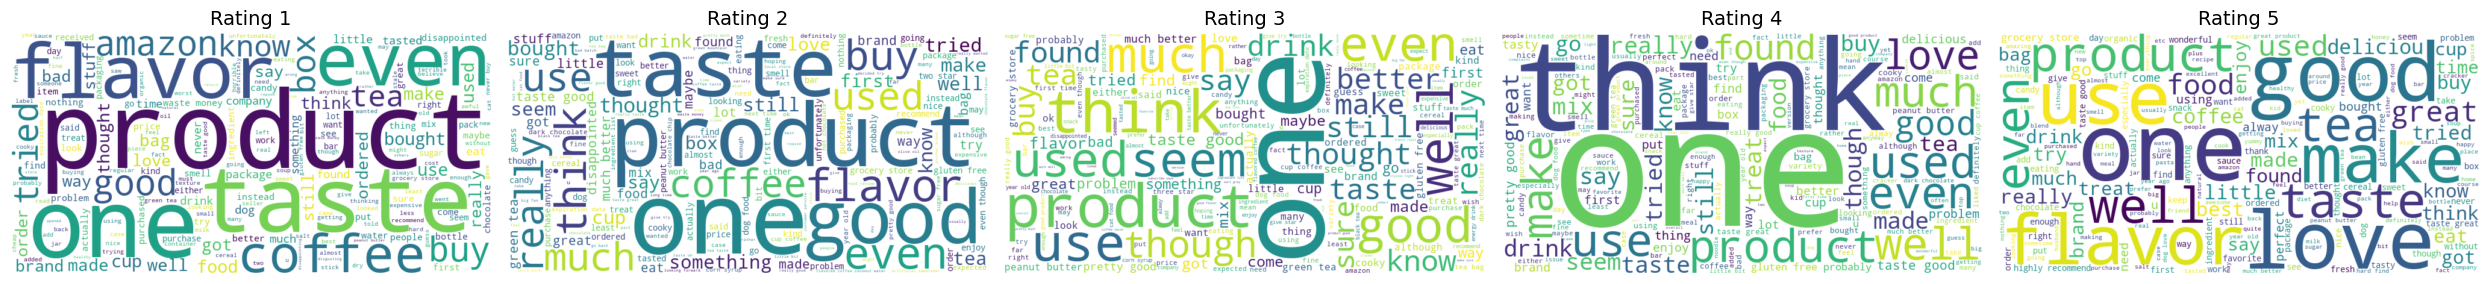

In [54]:
ratings = sorted(data['rating'].unique())
num_ratings = len(ratings)

# Create subplots (rows=1, columns=number of unique ratings)
fig, axes = plt.subplots(1, num_ratings, figsize=(5 * num_ratings, 5))

for ax, i in zip(axes, ratings):
    text = " ".join(data[data['rating'] == i]['cleaned_review'].astype(str))
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f"Rating {i}", fontsize=14)

plt.tight_layout()
plt.savefig("all_ratings_wordcloud.png", dpi=300, bbox_inches='tight')
plt.show()

In [22]:
# preview of sample reviews per rating
for r in sorted(data["rating"].unique()):
    print(f"sample review of rating {r}")
    display(data[data["rating"] == r]["cleaned_review"].sample(min(5, len(data[data["rating"] == r]))).to_list())

sample review of rating 1


['dont know charge bundling package got order wrong twice received half order paid twice nowi hope someone else happen thats writing bad review',
 'disappointed find tree purchased gift someone died continuous care month',
 'product complete ripoff gave percent paid product complete ripoff',
 'avid keurig user tassimo convert thrilled finally find starbucks kcups arrived purchased box kcups pike placeroast amazon taste didnt disappoint satisfied feel rival taste cup purchased starbucks store unfortunately price also rival cup purchased starbucks storeheres math drinking caribou blend coffee pointcaribou blend average cupstarbucks cupwe understand starbucks premium coffee dont expect cheap caribou also premium coffee afford either principle suspecting starbucks corporate folk set price weve decided stay caribou based household coffee consumption would pay whopping year starbucks going vote stick caribou kindle owner feel like publisher price gouging experienced set price amazon',
 'love

sample review of rating 2


['soup two specific direction cooking microwave without microwave although direction preparing rather simple dealing easy cooked microwave bowl hot rather cumbersome hold onto draining problem may need protectionthe bowl soup nutrition fact claim calorie total fat ogm saturated trans fat sodium high contains gm carbohydrate purchased lack fatyou add chicken tofu stir fried vegetable fresh chopped vegetable keep mind meal come small packet dried tofu carrot spinach topping vegetable packet consists small piece dry dehydrated appetizingthere odd flavor consistency noodle sauce tasty flavorful first impression critical im sure would try annie chuns dish crave teriyaki noodle bowl rizzo',
 'placed order one oz bag mm receive bag oz peanut mm although mean received oz overall product listing inaccurate',
 'disappointing product plenty salt much truffle flavor aroma mainly tiny percentage content made truffle piece dont know whether rival product using one doesnt add much flavor food aside s

sample review of rating 3


['two traditional striped cat eat mostly dry science diet cat food nucat vitamin added also get iams canned chicken turkey beef day brownie prefers dry food eat canned food freshly opened pi like tried petite cuisine variety pack yellowfin snapper tuna sole tuna shrimp petite cuisine variety pack chinese chicken chicken pot pie course sixteen day cat got onequarter day alternated can chicken fish varietiesat first feline enthusiastic tired chicken pi would lick gravy brownie refused even look fish better received like yellowfin tuna shrimp cat vote two six varietiesthere however question mercury ocean fish study japan found cat ate tuna higher concentration mercury fur cat ate dry cat food study result discussed article find web using search term tuna fish posted question petite cuisine web site whether tested product mercury received answer conclusion may ok give cat fish occasional treat steady diet',
 'bad cheesy would hoped remember better kid',
 'tried year ago thought great certa

sample review of rating 4


['easy add water one egg simple easy make minute adding item mix doesnt provide result basic turned good',
 'great bold coffee avid starbucks drinker prefer darker roast one fit bill mei also like timothy midnight magictimothys rainforest espresso coffee people bold black tiger gloria jean black gold',
 'mix wheat germ flaxseed milk every morning love beneficial every part body wouldnt think going without highly recommended wheat germ',
 'knew taste pleasure roller coaster disappointed brewingmy tastebud began waterwhat liked flavored coffee didnt get back taste often get coffee even coffee cooled still delicious sometimes like chill coffee',
 'unlike bar crunchy theyre loaded nut seed husband love wish organic natural mean healthy know']

sample review of rating 5


['spent time searching alcohol free rum flavor make daiquiri sorbet lorann produced best flavor thus far taste outstanding blow away competitor tried baking yet attempted imagine would similar result price quite reasonable oz bottle although much multiple bottle ordered save shipping natural artificial ingredient would prefer natural thats price im willing pay flavor predict remain alcohol free rum flavor choice',
 'started using purina second nature dog litter one day brought puppy home breeder week old within day trained use litter box thought product bit expensive litter soon found worth used various cheaper brand period month order save money found werent absorbent untrackable important odor none tried actually stunk house thrown away immediately refuse use anything second nature im satisfied result',
 'organic instant coffee rich enough taste good camping put emergency stash suppplies intend put jar gift basket got first place k cup starting environmental problem wanted quick morn

In [23]:
data['rating'].value_counts()

rating
4    100610
3     83792
5     67595
2     50589
1     33745
Name: count, dtype: int64

#### Train test split

In [11]:
x = data["cleaned_review"] # training
y = data["rating"]         # testing

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42)

print("Train set:\n", y_train.value_counts().to_dict())
print("Test set:\n", y_test.value_counts().to_dict())

Train set:
 {4: 80510, 3: 67110, 5: 54086, 2: 40481, 1: 26997}
Test set:
 {4: 20128, 3: 16778, 5: 13521, 2: 10120, 1: 6749}


#### Vectorization (TF-IDF)

In [ ]:
#converts text data into numerical features using TF-IDF(Term Frequency Inverse Document Frequency)
# vectorizer = TfidfVectorizer(max_features=5000) #limits the number of features/unique words to the top 5000 most imp words in dataset.
# X_train_tfidf = vectorizer.fit_transform(x_train)
# X_test_tfidf = vectorizer.transform(x_test)

# print("TF-IDF Train shape:", X_train_tfidf.shape)
# print("TF-IDF Test shape:", X_test_tfidf.shape)

TF-IDF Train shape: (269064, 5000)
TF-IDF Test shape: (67267, 5000)


In [12]:
vectorizer = TfidfVectorizer(
    max_features=15000,  # expand vocabulary      (befor 5000)
    ngram_range=(1,2),   # include bigrams
    min_df=3,            # ignore very rare words
    max_df=0.9           # ignore overly common words
)                        # Increasing max_features and adding bigrams can capture more contextual information.


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape:", X_test_tfidf.shape)


TF-IDF Train shape: (269184, 15000)
TF-IDF Test shape: (67296, 15000)


In [14]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


#### Logistic Regression

Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Logistic Regression Best Params: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.6709
              precision    recall  f1-score   support

           1     0.7239    0.6343    0.6761      6749
           2     0.7007    0.7078    0.7042     10120
           3     0.6728    0.7065    0.6892     16778
           4     0.6410    0.6665    0.6535     20128
           5     0.6687    0.6236    0.6454     13521

    accuracy                         0.6709     67296
   macro avg     0.6814    0.6678    0.6737     67296
weighted avg     0.6718    0.6709    0.6707     67296



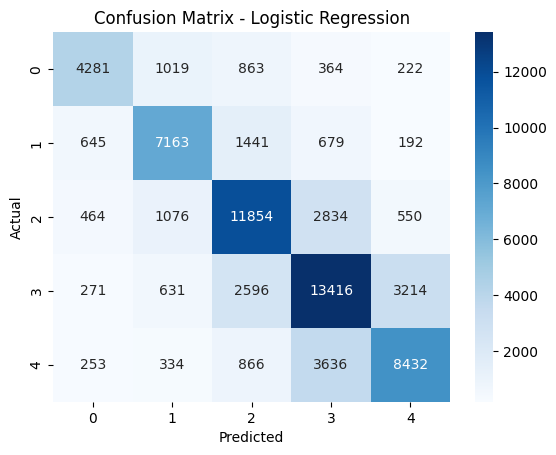

In [15]:
# Hyperparameter tuning
lr_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_tfidf, y_train)

# Evaluate
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_tfidf)

print("\n Logistic Regression Best Params:", lr_grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr, digits=4))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Logistic Regression - Inferences.
- Best Parameters: {'C': 10, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
- Accuracy: 67.09%, indicates a fair ability to classify the review ratings based on text features (TF-IDF vectors).
- The macro and weighted averages of precision, recall, and F1-score are consistent (~0.67), showing that the model performs fairly evenly across all rating classes.

Confusion Matrix Insights

- The matrix shows strong diagonal dominance, indicating decent classification accuracy overall.
- Misclassifications are mostly between neighboring ratings (e.g., 3-4, 2-3), which is common in ordinal sentiment data where boundaries between classes are subtle.
- The model rarely confuses extreme classes (1 and 5), suggesting it captures sentiment polarity reasonably well
Overall,
- Logistic Regression provides a balanced baseline model with steady results across classes.
- However, the model might struggle to capture nuanced language features or contextual sentiment shifts since TF-IDF + Logistic Regression are linear and do not capture deeper semantics.

#### Linear SVM

Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Linear SVM Best Params: {'C': 10, 'class_weight': None, 'loss': 'squared_hinge'}
Accuracy: 0.6553
              precision    recall  f1-score   support

           1     0.7024    0.6345    0.6667      6749
           2     0.6839    0.6887    0.6863     10120
           3     0.6589    0.6853    0.6718     16778
           4     0.6310    0.6455    0.6382     20128
           5     0.6444    0.6182    0.6311     13521

    accuracy                         0.6553     67296
   macro avg     0.6642    0.6544    0.6588     67296
weighted avg     0.6558    0.6553    0.6552     67296



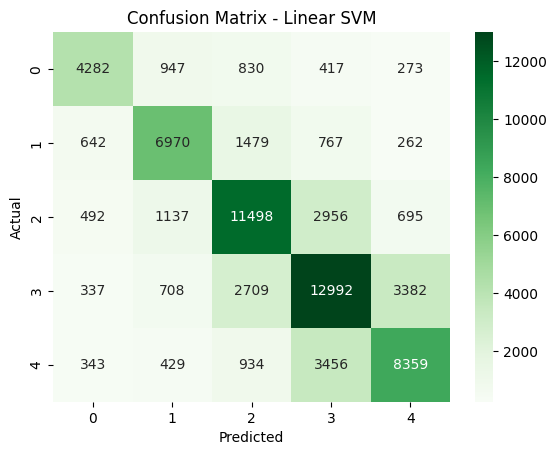

In [16]:
# Hyperparameter tuning
svm_params = {
    'C': [0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'loss': ['hinge', 'squared_hinge']
}

svm_grid = GridSearchCV(
    LinearSVC(max_iter=2000),
    svm_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
svm_grid.fit(X_train_tfidf, y_train)

# Evaluate
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_tfidf)

print("\n Linear SVM Best Params:", svm_grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, y_pred_svm), 4))
print(classification_report(y_test, y_pred_svm, digits=4))

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Linear SVM
- Best Parameters: {'C': 10, 'class_weight': None, 'loss': 'squared_hinge'}
- Accuracy: 65.53% ,which is slightly lower than Logistic Regression (67.1%).
- The Linear SVM model achieved an overall accuracy of 65.5%, which is slightly lower than Logistic Regression (67.1%).
- The macro and weighted averages of precision, recall, and F1-score are all around 0.65, indicating balanced but modest performance.

Confusion Matrix Insights
- The confusion matrix shows a similar pattern to Logistic Regression, with the major errors between adjacent ratings (3-4, 2-3).
- The model maintains reasonable diagonal strength, confirming it correctly identifies most classes.
- Misclassifications are less random but more concentrated around mid-scale ratings, suggesting SVM has difficulty distinguishing between moderate ratings.

Overall

- The SVM performs comparably to Logistic Regression but shows slightly lower accuracy and F1-scores across most classes.
- Despite being a strong linear classifier, Linear SVM doesn’t provide a significant advantage over Logistic Regression when both use TF-IDF features — this suggests that the dataset may not have strong linear separability.
- Both models face the same challenge, confusion between adjacent ratings, indicating that deeper or nonlinear models might better capture nuanced sentiment patterns.

#### Naive Bayes

Fitting 3 folds for each of 8 candidates, totalling 24 fits

 Naive Bayes Best Params: {'alpha': 0.1, 'fit_prior': True}
Accuracy: 0.5529
              precision    recall  f1-score   support

           1     0.5910    0.4570    0.5154      6749
           2     0.6386    0.3317    0.4366     10120
           3     0.5319    0.5746    0.5524     16778
           4     0.5135    0.6920    0.5896     20128
           5     0.6217    0.5322    0.5735     13521

    accuracy                         0.5529     67296
   macro avg     0.5794    0.5175    0.5335     67296
weighted avg     0.5664    0.5529    0.5466     67296



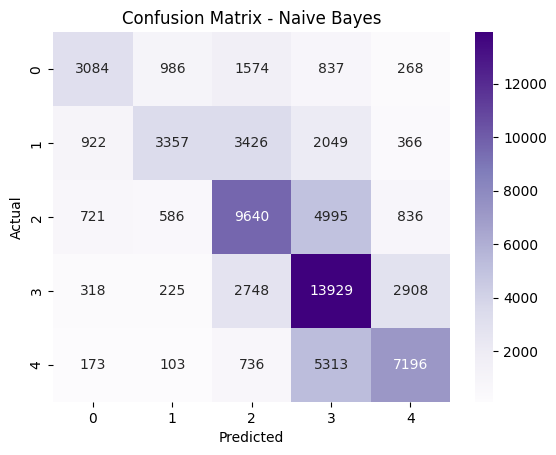

In [17]:
nb_params = {
    'alpha': [0.1, 0.5, 1.0, 2.0],     # smoothing parameter
    'fit_prior': [True, False]
}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)

nb_grid.fit(X_train_tfidf, y_train)

# Evaluate
nb_best = nb_grid.best_estimator_
y_pred_nb = nb_best.predict(X_test_tfidf)

print("\n Naive Bayes Best Params:", nb_grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, y_pred_nb), 4))
print(classification_report(y_test, y_pred_nb, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - Naive Bayes")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Multinomial Naive Bayes

- Best Parameters: { alpha = 0.1, fit_prior = True}
- Accuracy: 55.29%, indicates the model captures some signal but struggles to fully distinguish between classes
Per-Class Observations:
- Rating 1 & 2: Lower recall (0.45 & 0.33) means the model struggles to identify very low ratings.
- Rating 3: Balanced precision and recall, performs best here.
- Rating 4: High recall (0.69) — tends to overpredict this class.
- Rating 5: Moderate precision (0.62) but recall only 0.53, misclassifies some positive reviews.

Confusion Matrix Insights

- Most reviews rated 3 or 4 are correctly identified(the matrix’s darkest regions.)
- Model confuses 3 and 4 heavily, which makes sense since their wording patterns are often similar (“good” vs “very good”).
- Lower ratings (1 & 2) get scattered across other classes, especially misclassified as 3.
- Class 5 also leaks into class 4.

Overall,
- Naive Bayes performs reasonably for a baseline text model but shows class imbalance or semantic overlap issues.

In [21]:
vectorizer = TfidfVectorizer(
    max_features=1500,  # expand vocabulary      (befor 5000)
    ngram_range=(1,2),   # include bigrams
    min_df=3,            # ignore very rare words
    max_df=0.9           # ignore overly common words
)                        # Increasing max_features and adding bigrams can capture more contextual information.


X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Test shape:", X_test_tfidf.shape)

TF-IDF Train shape: (269184, 1500)
TF-IDF Test shape: (67296, 1500)


Logistic Regression

Fitting 3 folds for each of 12 candidates, totalling 36 fits

 Logistic Regression Best Params: {'C': 1, 'class_weight': None, 'penalty': 'l2', 'solver': 'lbfgs'}
Accuracy: 0.5183
              precision    recall  f1-score   support

           1     0.5506    0.4771    0.5112      6749
           2     0.4528    0.3438    0.3908     10120
           3     0.4776    0.4974    0.4873     16778
           4     0.5165    0.5898    0.5507     20128
           5     0.5985    0.5892    0.5938     13521

    accuracy                         0.5183     67296
   macro avg     0.5192    0.4995    0.5068     67296
weighted avg     0.5171    0.5183    0.5156     67296



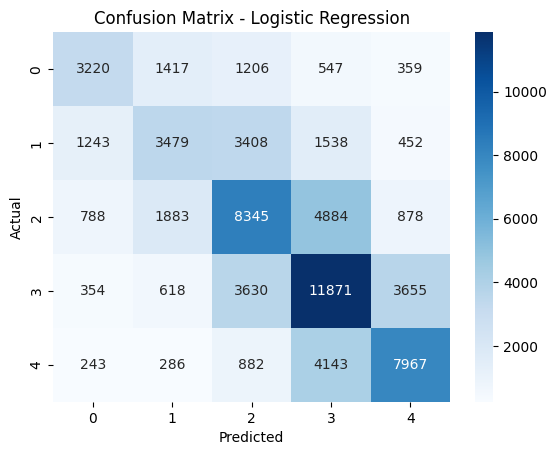

In [22]:
# Hyperparameter tuning
lr_params = {
    'C': [0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    scoring='accuracy',
    cv=3,
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train_tfidf, y_train)

# Evaluate
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_tfidf)

print("\n Logistic Regression Best Params:", lr_grid.best_params_)
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print(classification_report(y_test, y_pred_lr, digits=4))

cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()